### Import Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



### Load Dataset

In [3]:
df = sns.load_dataset("tips")
df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Explore Data

In [4]:
print("Shape:", df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())


Shape: (244, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.1275

### Basic Data Cleaning

In [5]:
categorical_cols = ['sex', 'smoker', 'day', 'time']
for col in categorical_cols:
    df[col] = df[col].astype('category')


In [6]:
# Average Bill & Tip

avg_bill = np.mean(df['total_bill'])
avg_tip  = np.mean(df['tip'])
print(avg_bill, avg_tip)


19.78594262295082 2.99827868852459


In [7]:
# Median and Standard Deviation
median_bill = np.median(df['total_bill'])
std_tip = np.std(df['tip'])


### Univariate Visualisation

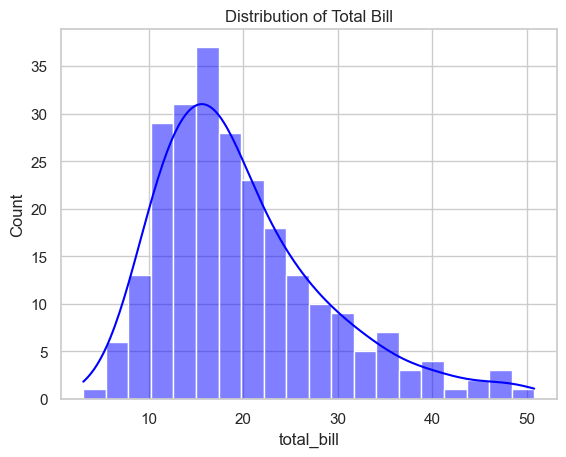

In [9]:
# Histogram of Total Bill
sns.histplot(df['total_bill'], kde=True, bins=20, color="blue")
plt.title("Distribution of Total Bill")
plt.show()


Insights

Most bills are between $10–25

Few very high spenders appear as right-tail outliers

### Bivariate Visualisation

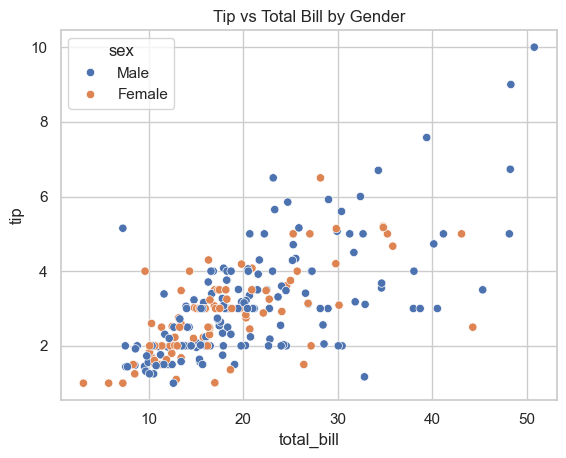

In [10]:
#Tip vs Total Bill Scatterplot

sns.scatterplot(data=df, x='total_bill', y='tip', hue='sex')
plt.title("Tip vs Total Bill by Gender")
plt.show()


Insights

Tips grow with bill size

Male customers generally tip slightly higher

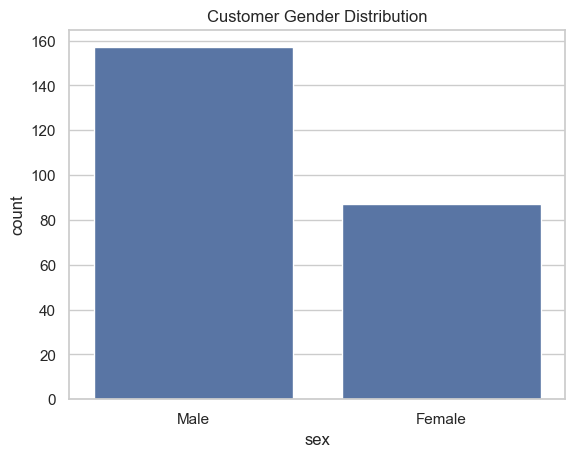

In [13]:
#Countplot: Customers by Gender
sns.countplot(x='sex', data=df)
plt.title("Customer Gender Distribution")
plt.show()



Insights:

More male customers than female

### Multivariate Visualisation

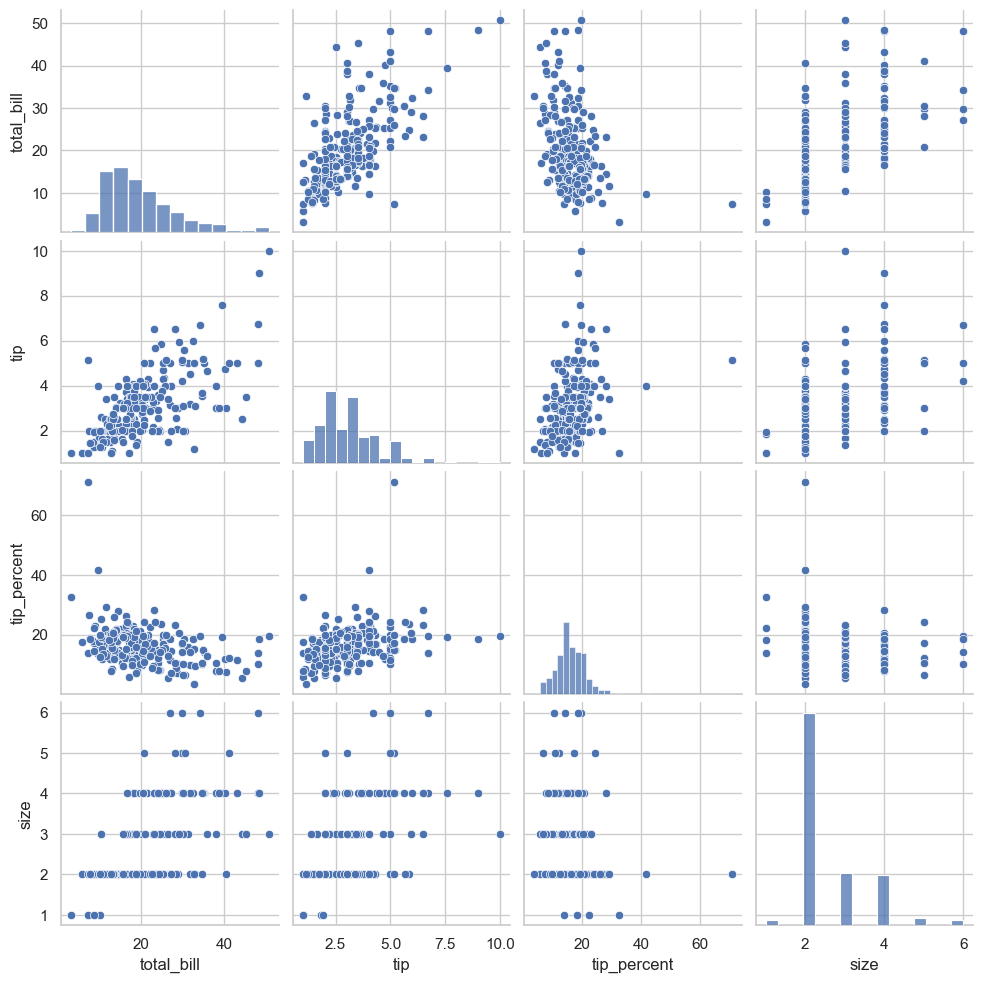

In [16]:
# Pairplot
df['tip_percent'] = df['tip'] / df['total_bill'] * 100
sns.pairplot(df[['total_bill','tip','tip_percent','size']], hue=None)
plt.show()


Insights:

Tip % is relatively consistent regardless of bill amount

Larger groups pay higher bills (positive trend)

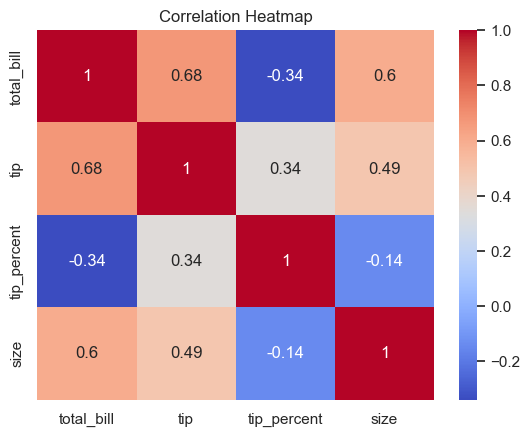

In [18]:
#Heatmap of Correlation
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")

# Create tip_percent if missing
df['tip_percent'] = df['tip'] / df['total_bill'] * 100

# 1. Create correlation matrix
corr = df[['total_bill','tip','tip_percent','size']].corr()

# 2. Plot heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


Insights:

total_bill ↔ tip: strongly correlated

size ↔ total_bill: moderately correlated

tip_percent weakly correlated with others → interesting behavioral insight

In [19]:
# Using NumPy for some summary values
avg_total = np.mean(df['total_bill'])
median_total = np.median(df['total_bill'])
std_total = np.std(df['total_bill'], ddof=0)   # population std
var_total = np.var(df['total_bill'], ddof=0)

# Using pandas for more:
skew_tip = df['tip'].skew()
kurt_tip = df['tip'].kurtosis()  # excess kurtosis
percentiles = np.percentile(df['total_bill'], [5,25,50,75,95])

print("Average total bill (np):", avg_total)
print("Median total bill (np):", median_total)
print("Std total bill (np):", std_total)
print("Variance total bill (np):", var_total)
print("Tip skewness:", skew_tip)
print("Tip kurtosis:", kurt_tip)
print("Total bill percentiles (5,25,50,75,95):", percentiles)


Average total bill (np): 19.78594262295082
Median total bill (np): 17.795
Std total bill (np): 8.884150577771132
Variance total bill (np): 78.92813148851114
Tip skewness: 1.4654510370979401
Tip kurtosis: 3.648375873352852
Total bill percentiles (5,25,50,75,95): [ 9.5575 13.3475 17.795  24.1275 38.061 ]


Insights

--Skewness (tip)

Tips are mostly small.

Few large tips create right skew.

--Kurtosis (tip)

Tip data has outliers.

Distribution is more peaked than normal.

--Percentiles (total_bill)

Typical customer spends near the median.

High percentiles show a few big spenders.

### Statistics

In [21]:
# by day
by_day = df.groupby('day').agg(
    count_total=('total_bill','count'),
    mean_bill=('total_bill','mean'),
    median_bill=('total_bill','median'),
    mean_tip=('tip','mean'),
    mean_tip_pct=('tip_percent','mean'),
    std_tip_pct=('tip_percent','std')
).reset_index()
print(by_day)

# by sex & smoker
by_sex_smoker = df.groupby(['sex','smoker']).agg(
    n=('tip','count'),
    mean_tip=('tip','mean'),
    mean_tip_pct=('tip_percent','mean'),
    median_bill=('total_bill','median')
).reset_index()
print(by_sex_smoker)


    day  count_total  mean_bill  median_bill  mean_tip  mean_tip_pct  \
0  Thur           62  17.682742        16.20  2.771452     16.127563   
1   Fri           19  17.151579        15.38  2.734737     16.991303   
2   Sat           87  20.441379        18.24  2.993103     15.315172   
3   Sun           76  21.410000        19.63  3.255132     16.689729   

   std_tip_pct  
0     3.865182  
1     4.766531  
2     5.129259  
3     8.473889  
      sex smoker   n  mean_tip  mean_tip_pct  median_bill
0    Male    Yes  60  3.051167     15.277118        20.39
1    Male     No  97  3.113402     16.066872        18.24
2  Female    Yes  33  2.931515     18.215035        16.27
3  Female     No  54  2.773519     15.692097        16.69


C:\Users\kopur\AppData\Local\Temp\ipykernel_18484\147315162.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_day = df.groupby('day').agg(
C:\Users\kopur\AppData\Local\Temp\ipykernel_18484\147315162.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_sex_smoker = df.groupby(['sex','smoker']).agg(


### Percentiles & IQR-based outlier detection

In [23]:
# IQR for tip_percent
Q1 = df['tip_percent'].quantile(0.25)
Q3 = df['tip_percent'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df['tip_percent'] < lower) | (df['tip_percent'] > upper)]
print("IQR:", IQR, "lower,upper:", lower, upper)
print("Outliers count (tip_percent):", len(outliers))
outliers[['total_bill','tip','tip_percent','sex','day','time','size']].head()


IQR: 6.234812458689152 lower,upper: 3.5605174862758684 28.49976732103248
Outliers count (tip_percent): 4


,total_bill,tip,tip_percent,sex,day,time,size
67,3.07,1.00,32.573290,Female,Sat,Dinner,1
172,7.25,5.15,71.034483,Male,Sun,Dinner,2
178,9.60,4.00,41.666667,Female,Sun,Dinner,2
232,11.61,3.39,29.198966,Male,Sat,Dinner,2


Insights

You can say: “There are N outlier tip_pct values — usually extremely generous tips or tiny/zero tips.”

### Z-scores (standardized) for detecting extreme total_bill values

In [24]:
from scipy import stats  # optional; if SciPy not available, compute manually with numpy
# if SciPy not available, use:
tb_mean = df['total_bill'].mean()
tb_std = df['total_bill'].std(ddof=0)
df['total_bill_z'] = (df['total_bill'] - tb_mean) / tb_std

# mark extremes
z_extremes = df[np.abs(df['total_bill_z']) > 2]   # roughly outside 95% interval
print("Number of bills with |z|>2:", len(z_extremes))
z_extremes[['total_bill','tip','size','day']]


Number of bills with |z|>2: 14


,total_bill,tip,size,day
23,39.42,7.58,4,Sat
56,38.01,3.00,4,Sat
59,48.27,6.73,4,Sat
95,40.17,4.73,4,Fri
102,44.30,2.50,3,Sat
112,38.07,4.00,3,Sun
142,41.19,5.00,5,Thur
156,48.17,5.00,6,Sun
170,50.81,10.00,3,Sat
182,45.35,3.50,3,Sun


Insights

Extreme bills (|z|>2) are the high spenders; check if they skew means and consider winsorizing for robust stats.

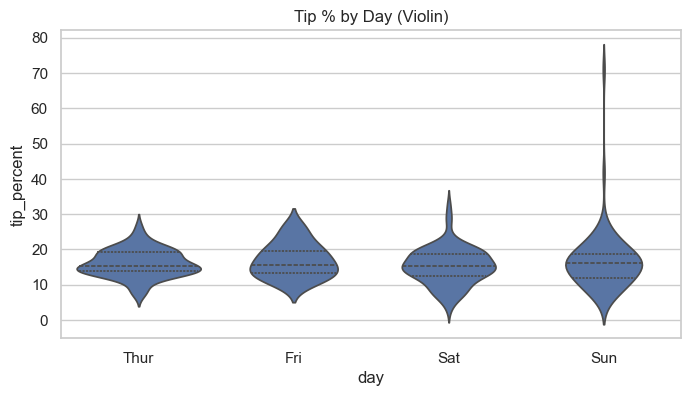

In [ ]:
# Violin plot: tip_percent by day
plt.figure(figsize=(8,4))
sns.violinplot(x='day', y='tip_percent', data=df, inner='quartile')
plt.title('Tip % by Day (Violin)')
plt.show()


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer

df = sns.load_dataset("tips")

# Create tip_percent column
df['tip_percent'] = df['tip'] / df['total_bill'] * 100
df.head()



,total_bill,tip,sex,smoker,day,time,size,tip_percent
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


### Countplot before Encoding

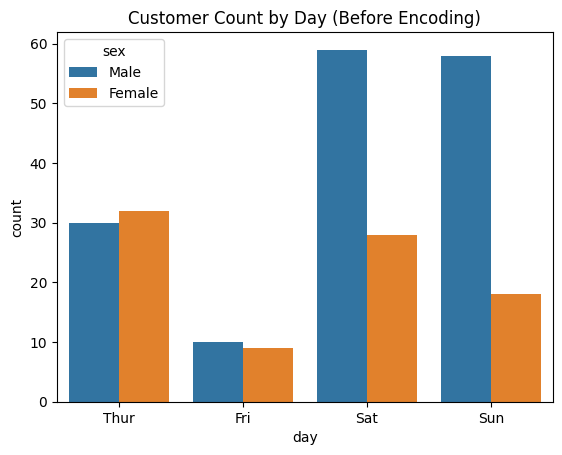

In [5]:
sns.countplot(x="day", data=df, hue="sex")
plt.title("Customer Count by Day (Before Encoding)")
plt.show()



### One Hot Encoding

In [6]:
df_encoded = pd.get_dummies(df,
                             columns=["sex", "smoker", "day", "time"],
                             drop_first=True)


In [11]:
df_encoded["Sex_Category"] = df_encoded["sex_Female"].map({1: "Male", 0: "Female"})



### Skewness and Kurtosis

In [14]:
import seaborn as sns
import pandas as pd
import numpy as np

# load
df = sns.load_dataset("tips")

# check current columns
print("Columns before:", df.columns.tolist())

# create tip_percent if missing (safe, idempotent)
if 'tip_percent' not in df.columns:
    df['tip_percent'] = df['tip'] / df['total_bill'] * 100

print("Columns after:", df.columns.tolist())

# Now compute skewness & kurtosis
cols = ["total_bill", "tip", "tip_percent", "size"]

print("\n===== SKEWNESS & KURTOSIS REPORT (TIPS DATASET) =====\n")
for col in cols:
    skew_val = df[col].skew()
    kurt_val = df[col].kurtosis() + 3   # convert Fisher→Pearson kurtosis if you prefer
    print(f"Column: {col}")
    print(f"  Skewness = {skew_val:.4f}")
    print(f"  Kurtosis = {kurt_val:.4f}")
    print("-" * 40)


Columns before: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']
Columns after: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size', 'tip_percent']

===== SKEWNESS & KURTOSIS REPORT (TIPS DATASET) =====

Column: total_bill
  Skewness = 1.1332
  Kurtosis = 4.2185
----------------------------------------
Column: tip
  Skewness = 1.4655
  Kurtosis = 6.6484
----------------------------------------
Column: tip_percent
  Skewness = 3.3492
  Kurtosis = 30.1315
----------------------------------------
Column: size
  Skewness = 1.4479
  Kurtosis = 4.7317
----------------------------------------


### Z-Score Outlier Detection

In [15]:
def detect_outliers_zscore(col):
    z = (df[col] - df[col].mean()) / df[col].std()
    return df[np.abs(z) > 3][[col]]

print("\n===== Z-Score Outlier Detection =====")

print("\nTotal Bill Outliers:")
print(detect_outliers_zscore("total_bill"))

print("\nTip Outliers:")
print(detect_outliers_zscore("tip"))

print("\nTip Percent Outliers:")
print(detect_outliers_zscore("tip_percent"))



===== Z-Score Outlier Detection =====

Total Bill Outliers:
     total_bill
59        48.27
156       48.17
170       50.81
212       48.33

Tip Outliers:
       tip
23    7.58
170  10.00
212   9.00

Tip Percent Outliers:
     tip_percent
172    71.034483
178    41.666667


### Yeo-Johnson PowerTransform


Processing Column: total_bill
Yeo-Johnson Skewness: 0.00021319243948587428
Yeo-Johnson Kurtosis: 0.21705843328340046


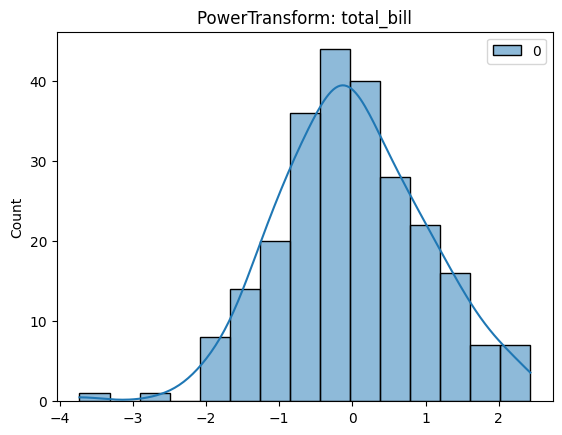


Processing Column: tip
Yeo-Johnson Skewness: 0.016092061718117997
Yeo-Johnson Kurtosis: -0.3402071807653897


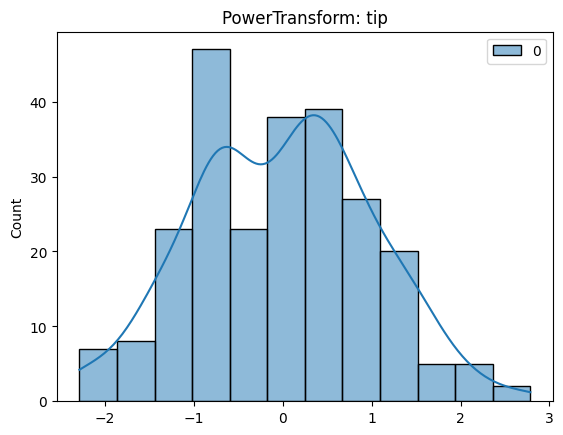


Processing Column: tip_percent
Yeo-Johnson Skewness: 0.03326530772222907
Yeo-Johnson Kurtosis: 2.9488924921190423


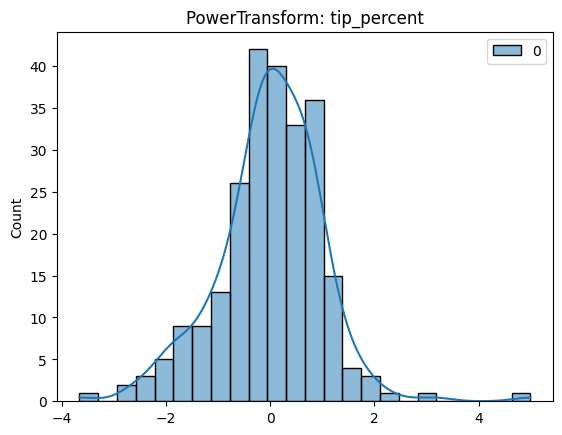

In [16]:
cols_to_transform = ["total_bill", "tip", "tip_percent"]

pt = PowerTransformer(method="yeo-johnson")

for col in cols_to_transform:
    print("\n==============================")
    print(f"Processing Column: {col}")
    print("==============================")

    transformed = pt.fit_transform(df[[col]])

    skew_val = pd.Series(transformed.reshape(len(df),)).skew()
    kurt_val = pd.Series(transformed.reshape(len(df),)).kurtosis()

    print("Yeo-Johnson Skewness:", skew_val)
    print("Yeo-Johnson Kurtosis:", kurt_val)

    sns.histplot(transformed, kde=True)
    plt.title(f"PowerTransform: {col}")
    plt.show()
